# inspect_model.ipynb — ported for spatial-manifolds

Faithful copy of `GRID-PATTERN-FORMATION/inspect_model.ipynb`.
Minimal changes: `sys.path` setup, MPS/CUDA/CPU device detection, `.cuda()` → `.to(device)`,
`model.RNN.weights[i]` → correct PyTorch attribute names, TF calls → numpy equivalents.

In [28]:
import sys, os
REPO_DIR = '/Users/harryclark/Documents/spatial-manifolds/GRID-PATTERN-FORMATION'
sys.path.insert(0, REPO_DIR)

import numpy as np
import torch
import scipy
import scipy.stats
import scipy.special
import scipy.ndimage
from tqdm import tqdm
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%load_ext autoreload
%autoreload 2

# Device: MPS (Apple Silicon) → CUDA → CPU
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print('device:', device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: mps


In [29]:
from utils                import generate_run_ID
from place_cells          import PlaceCells
from trajectory_generator import TrajectoryGenerator
from model                import RNN
from trainer              import Trainer

In [30]:
class Options:
    pass
options = Options()

options.save_dir        = '/tmp/inspect_model_grid_cells'
options.batch_size      = 200
options.sequence_length = 20
options.learning_rate   = 1e-4
options.Np              = 512
options.Ng              = 4096   # must match example_trained_weights.npy
options.place_cell_rf   = 0.12
options.surround_scale  = 2
options.RNN_type        = 'RNN'
options.activation      = 'relu'
options.weight_decay    = 1e-4
options.DoG             = True
options.periodic        = False
options.box_width       = 2.2
options.box_height      = 2.2
options.device          = device

options.run_ID = generate_run_ID(options)
os.makedirs(options.save_dir, exist_ok=True)
print('Run ID:', options.run_ID)

Run ID: steps_20_batch_200_RNN_4096_relu_rf_012_DoG_True_periodic_False_lr_00001_weight_decay_00001


In [31]:
place_cells          = PlaceCells(options)

# The example weights were trained with specific place cell centres that differ
# from what np.random.seed(0) produces (different numpy version at training time).
# Load the saved centres so encoder weights decode correctly.
pc_centers_path = os.path.join(REPO_DIR, 'models', 'example_pc_centers.npy')
pc_centers = np.load(pc_centers_path)
place_cells.us = torch.tensor(pc_centers, dtype=torch.float32).to(device)
print(f'Place cell centres loaded from file  shape={place_cells.us.shape}')

trajectory_generator = TrajectoryGenerator(options, place_cells)
model                = RNN(options, place_cells).to(device)
trainer              = Trainer(options, model, trajectory_generator, restore=False)

# Load pre-trained weights from the repository (no training needed)
from utils import load_trained_weights
weight_dir = os.path.join(REPO_DIR, 'models', 'example_trained_weights.npy')
load_trained_weights(model, trainer, weight_dir)
model.eval()

# Sanity check
with torch.no_grad():
    inputs_t, pos_t, pc_t = trajectory_generator.get_test_batch(batch_size=100)
    _, err = model.compute_loss(inputs_t, pc_t, pos_t)
print(f'Decoding error: {err.item()*100:.1f} cm  (should be ~5 cm for a good model)')

Place cell centres loaded from file  shape=torch.Size([512, 2])
Initializing new model from scratch.
Saving to: /tmp/inspect_model_grid_cells/steps_20_batch_200_RNN_4096_relu_rf_012_DoG_True_periodic_False_lr_00001_weight_decay_00001
Epoch: 0/1. Step 0/1. Loss: 6.37. Err: 99.11cm
Loaded trained weights.
Decoding error: 4.4 cm  (should be ~5 cm for a good model)


# Task statistics

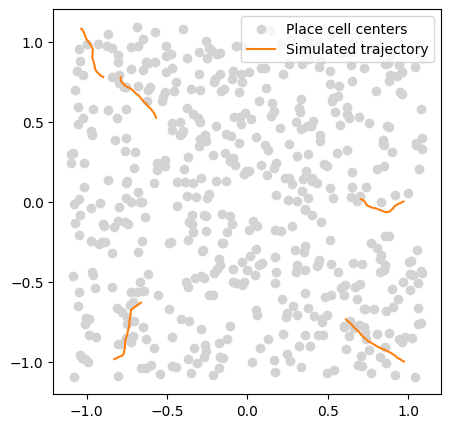

In [32]:
# Plot a few sample trajectories
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
us  = place_cells.us.cpu()
pos = pos.cpu()

plt.figure(figsize=(5, 5))
plt.scatter(us[:, 0], us[:, 1], c='lightgrey', label='Place cell centers')
for i in range(5):
    plt.plot(pos[:, i, 0], pos[:, i, 1], label='Simulated trajectory', c='C1')
    if i == 0:
        plt.legend()

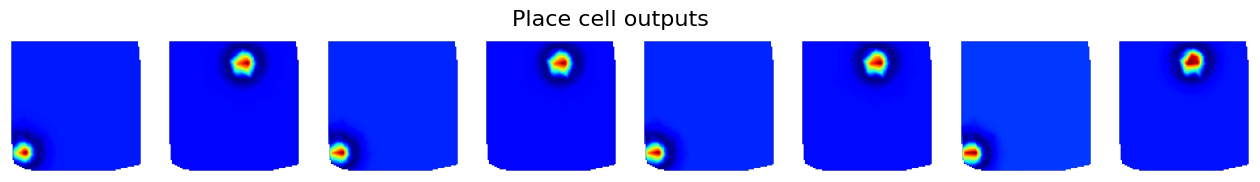

In [33]:
# Plot a few place cell outputs
pc_outputs = pc_outputs.reshape(-1, options.Np).detach().cpu()
pc = place_cells.grid_pc(pc_outputs[::100], res=100)

plt.figure(figsize=(16, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(pc[i], cmap='jet')
    plt.axis('off')

plt.suptitle('Place cell outputs', fontsize=16)
plt.show()

(np.float64(-0.5), np.float64(10.5), np.float64(-0.5), np.float64(10.5))

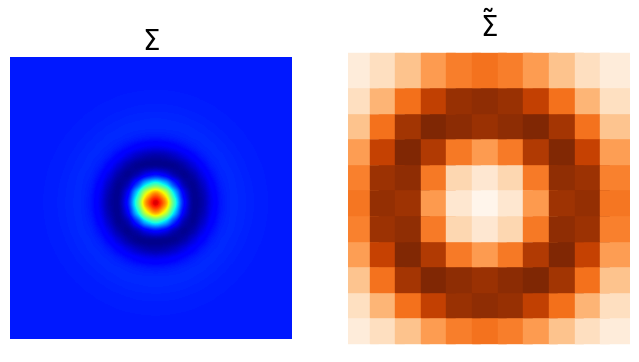

In [34]:
# Visualize place cell covariance matrix
Cmean = place_cells.compute_covariance(res=30)

# Fourier transform
Ctilde = np.fft.fft2(Cmean)
Ctilde[0, 0] = 0

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(Cmean, cmap='jet', interpolation='gaussian')
plt.axis('off')
plt.title(r'$\Sigma$', fontsize=20)

plt.subplot(122)
width = 6
idxs = np.arange(-width + 1, width)
x2, y2 = np.meshgrid(np.arange(2 * width - 1), np.arange(2 * width - 1))
plt.scatter(x2, y2, c=np.abs(Ctilde)[idxs][:, idxs],
            s=600, cmap='Oranges', marker='s')
plt.axis('equal')
plt.axis('off')
plt.title(r'$\tilde \Sigma$', fontsize=20)
plt.axis('off')

# Train model

In [35]:
# Pre-trained weights are already loaded above — no training required.
# Uncomment the block below only if you want to fine-tune or train from scratch.

# N_EPOCHS = 10; N_STEPS = 1000
# trainer.train(n_epochs=N_EPOCHS, n_steps=N_STEPS, save=True)
# plt.figure(figsize=(12,3))
# plt.subplot(121); plt.plot(trainer.err, c='black')
# plt.title('Decoding error (m)'); plt.xlabel('train step')
# plt.subplot(122); plt.plot(trainer.loss, c='black')
# plt.title('Loss'); plt.xlabel('train step')

print('Using pre-trained weights. Skip to ## Evaluate performance.')

Using pre-trained weights. Skip to ## Evaluate performance.


## Evaluate performance

(-1.1, 1.1)

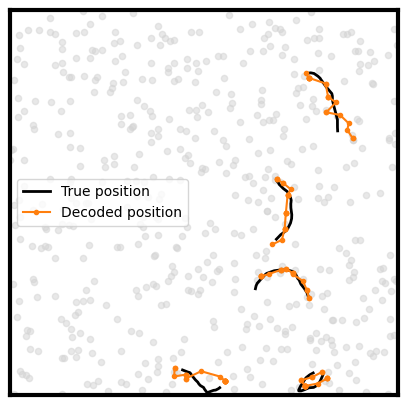

In [36]:
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
pos      = pos.cpu()
pred_pos = place_cells.get_nearest_cell_pos(model.predict(inputs)).cpu()
us       = place_cells.us.cpu()

fig = plt.figure(figsize=(5, 5))
ax  = fig.add_subplot(111)
for i in range(5):
    plt.plot(pos[:, i, 0], pos[:, i, 1], c='black', label='True position', linewidth=2)
    plt.plot(pred_pos[:, i, 0], pred_pos[:, i, 1], '.-', c='C1', label='Decoded position')
    if i == 0:
        plt.legend()
plt.scatter(us[:, 0], us[:, 1], s=20, alpha=0.5, c='lightgrey')
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(3)
plt.xticks([]); plt.yticks([])
plt.xlim([-options.box_width/2,  options.box_width/2])
plt.ylim([-options.box_height/2, options.box_height/2])

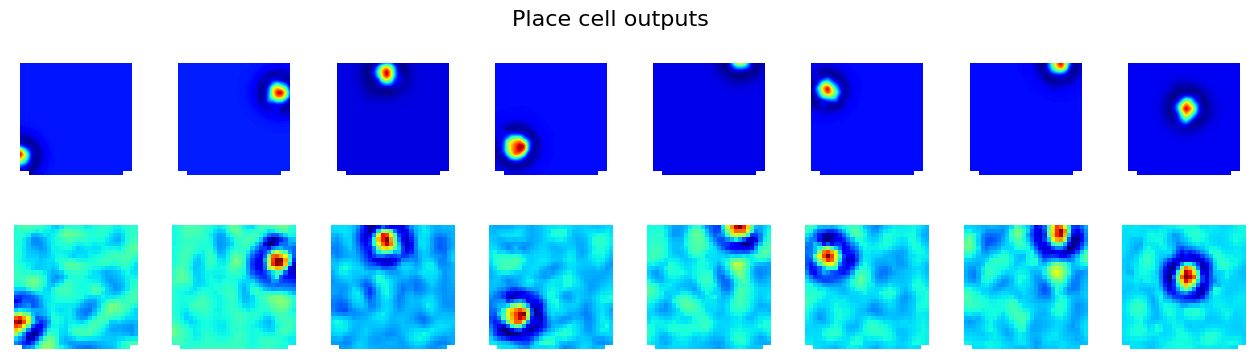

In [37]:
# Visualize predicted place cell outputs
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
preds      = model.predict(inputs)
preds      = preds.reshape(-1, options.Np).detach().cpu()
pc_outputs = model.softmax(pc_outputs).reshape(-1, options.Np).cpu()
pc_pred    = place_cells.grid_pc(preds[:100])
pc         = place_cells.grid_pc(pc_outputs[:100])

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(2, 8, i + 9)
    plt.imshow(pc_pred[2 * i], cmap='jet')
    if i == 0:
        plt.ylabel('Predicted')
    plt.axis('off')
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(pc[2 * i], cmap='jet', interpolation='gaussian')
    if i == 0:
        plt.ylabel('True')
    plt.axis('off')
plt.suptitle('Place cell outputs', fontsize=16)
plt.show()

# Ratemaps

(np.float64(-0.5), np.float64(859.5), np.float64(859.5), np.float64(-0.5))

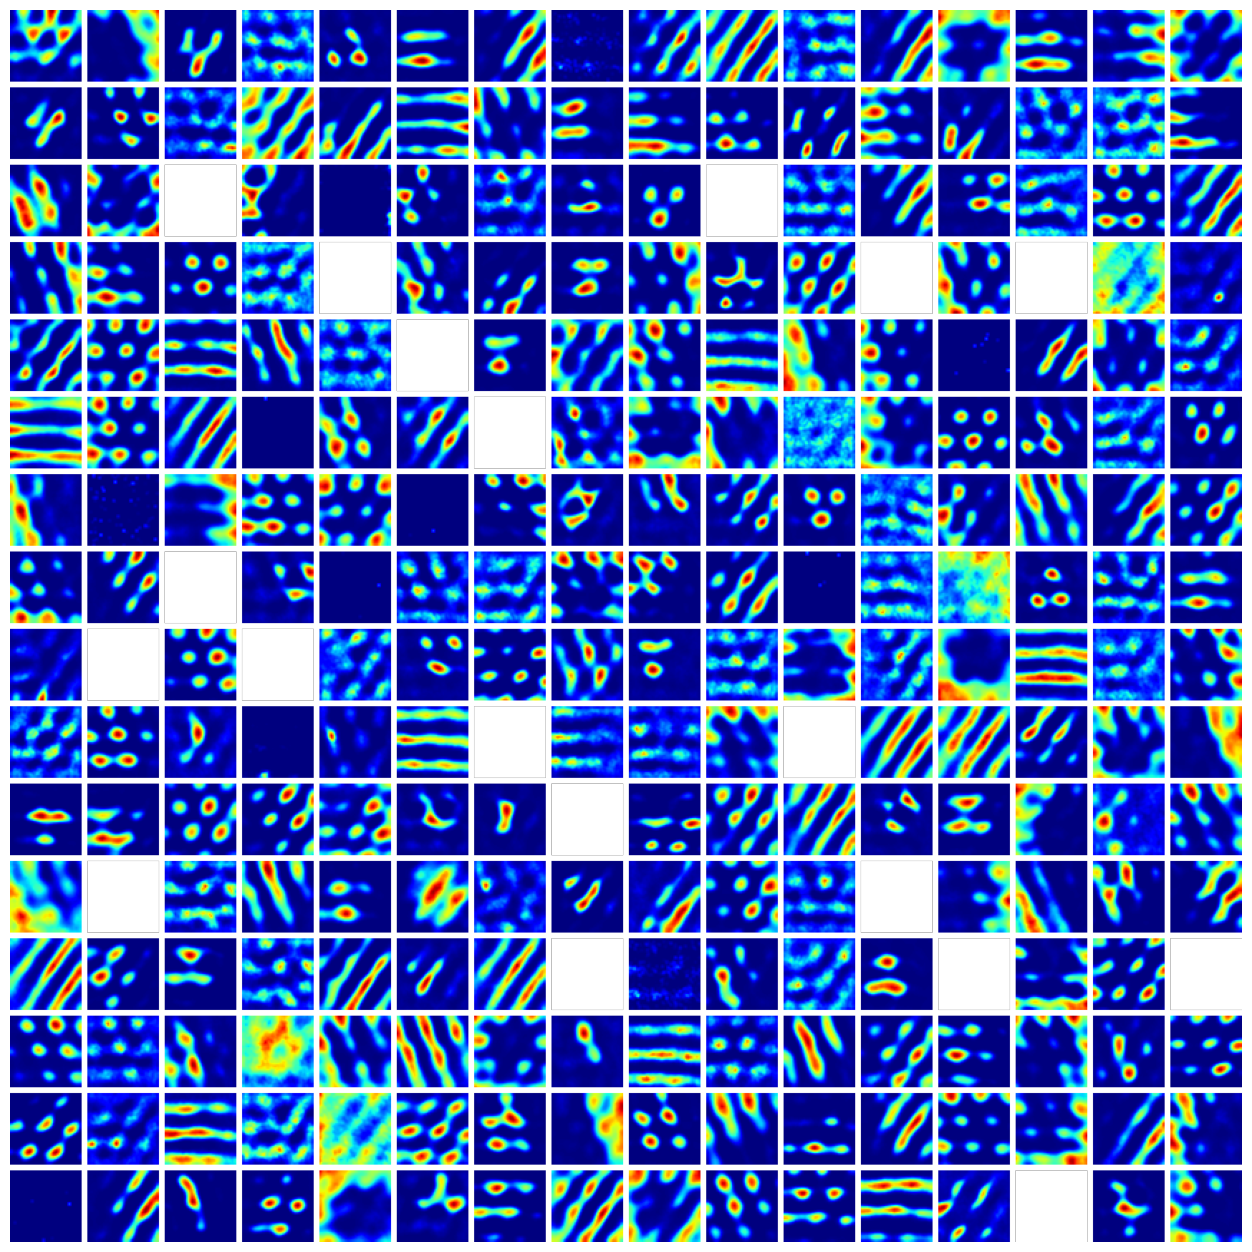

In [38]:
from visualize import compute_ratemaps, plot_ratemaps
res   = 50
n_avg = 100
Ng    = options.Ng

activations, rate_map, g, pos = compute_ratemaps(
    model, trajectory_generator, options, res=res, n_avg=n_avg, Ng=Ng)

# Compute a set of lo-res maps to use for evaluating grid score
lo_res = 20
_, rate_map_lores, _, _ = compute_ratemaps(
    model, trajectory_generator, options, res=lo_res, n_avg=n_avg, Ng=Ng)

n_plot = min(256, Ng)
plt.figure(figsize=(16, 4 * n_plot // 8 ** 2))
rm_fig = plot_ratemaps(activations, n_plot, smooth=True)
plt.imshow(rm_fig)
plt.axis('off')

## Grid scores

In [39]:
from scores import GridScorer

starts           = [0.2] * 10
ends             = np.linspace(0.4, 1.0, num=10)
box_width        = options.box_width
box_height       = options.box_height
coord_range      = ((-box_width/2, box_width/2), (-box_height/2, box_height/2))
masks_parameters = zip(starts, ends.tolist())
scorer           = GridScorer(lo_res, coord_range, masks_parameters)

score_60, score_90, max_60_mask, max_90_mask, sac, max_60_ind = zip(
    *[scorer.get_scores(rm.reshape(lo_res, lo_res)) for rm in tqdm(rate_map_lores)])

score_60 = np.array(score_60)
score_90 = np.array(score_90)

100%|██████████| 4096/4096 [00:43<00:00, 93.86it/s]


(np.float64(-0.5), np.float64(859.5), np.float64(427.5), np.float64(-0.5))

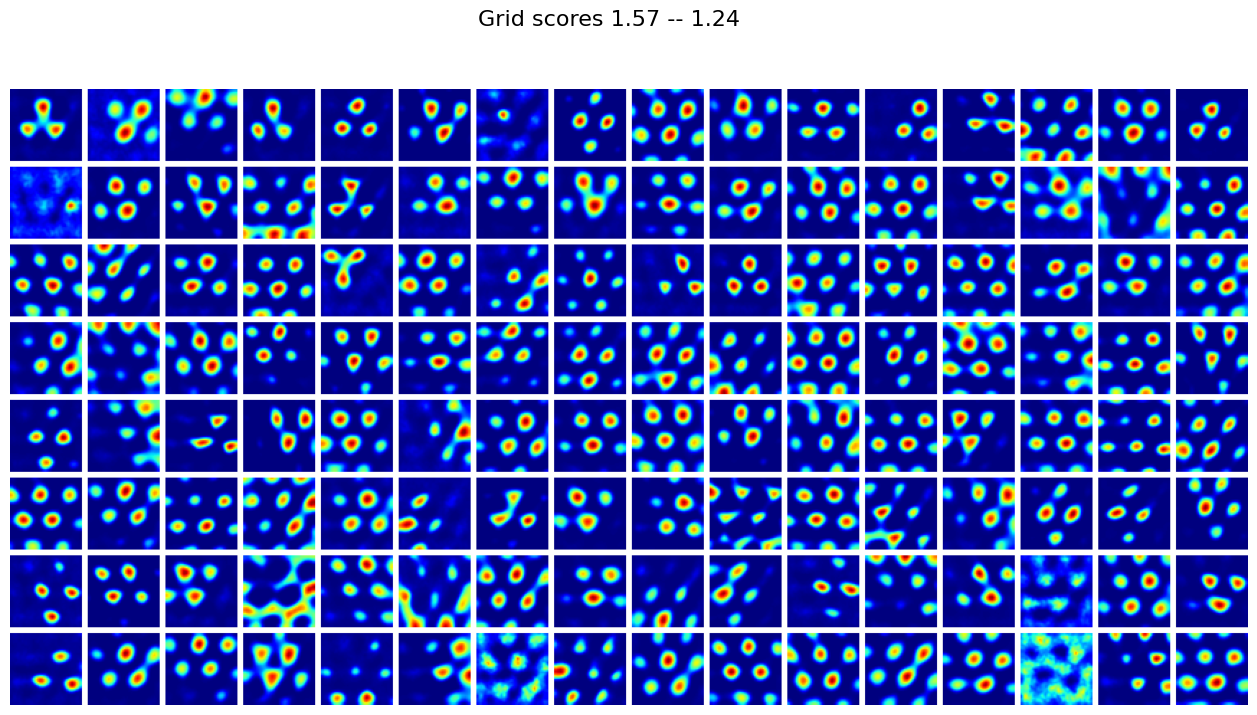

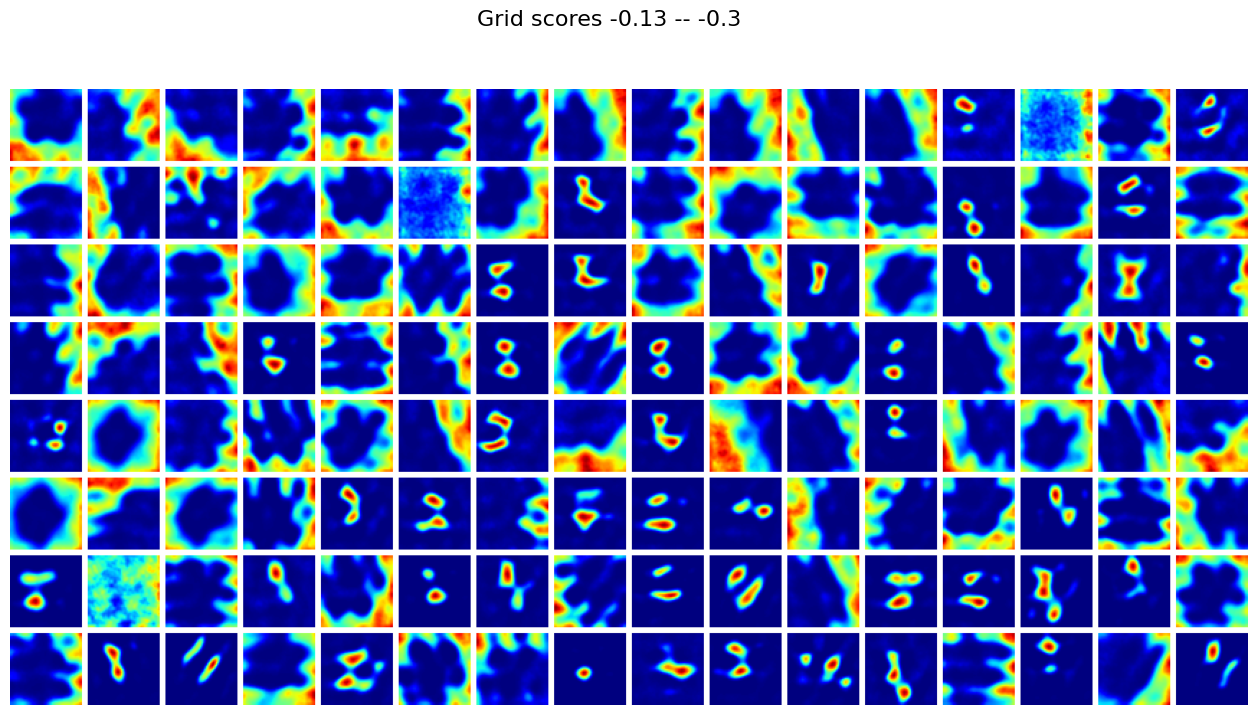

In [40]:
idxs   = np.flip(np.argsort(score_60))
n_plot = min(128, Ng)

# Plot high grid scores
plt.figure(figsize=(16, 4 * n_plot // 8 ** 2))
rm_fig = plot_ratemaps(activations[idxs], n_plot, smooth=True)
plt.imshow(rm_fig)
plt.suptitle('Grid scores ' + str(np.round(score_60[idxs[0]], 2))
             + ' -- ' + str(np.round(score_60[idxs[n_plot - 1]], 2)), fontsize=16)
plt.axis('off')

# Plot low grid scores
plt.figure(figsize=(16, 4 * n_plot // 8 ** 2))
rm_fig = plot_ratemaps(activations[np.flip(idxs)], n_plot, smooth=True)
plt.imshow(rm_fig)
plt.suptitle('Grid scores ' + str(np.round(score_60[idxs[-n_plot]], 2))
             + ' -- ' + str(np.round(score_60[idxs[-1]], 2)), fontsize=16)
plt.axis('off')

Text(0, 0.5, 'Count')

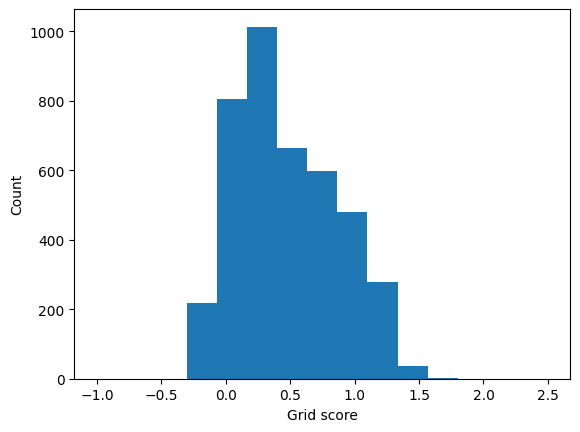

In [41]:
plt.hist(score_60, range=(-1, 2.5), bins=15)
plt.xlabel('Grid score')
plt.ylabel('Count')

Grid cells: 2563   Non-grid: 1533   (threshold=0.3)


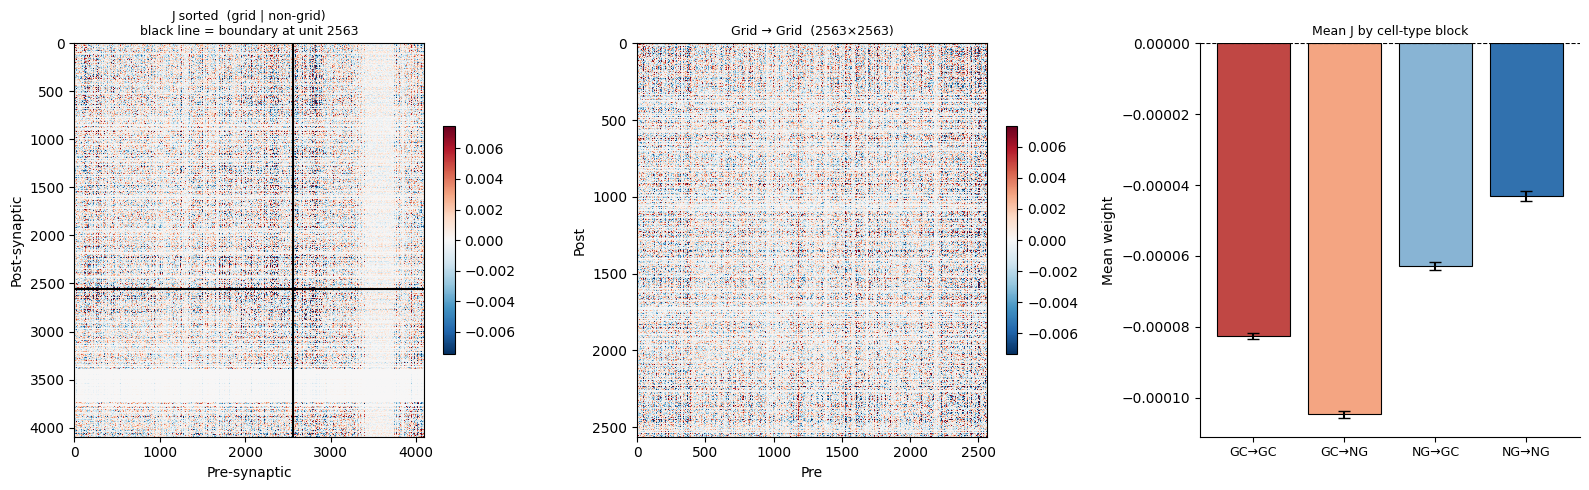

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ── Recurrent weight matrix ───────────────────────────────────────────────────
J = model.RNN.weight_hh_l0.detach().cpu().numpy()   # (Ng, Ng)

# ── Sort hidden units: grid cells first, then non-grid cells ──────────────────
# score_60 must already be computed (from the GridScorer cells above)
GRID_THRESH = 0.3
is_grid     = np.array(score_60) > GRID_THRESH

# Within each group, sort by score descending
grid_idx    = np.where( is_grid)[0][np.argsort(np.array(score_60)[ is_grid])[::-1]]
nongrid_idx = np.where(~is_grid)[0][np.argsort(np.array(score_60)[~is_grid])[::-1]]
order       = np.concatenate([grid_idx, nongrid_idx])

n_grid    = is_grid.sum()
n_nongrid = (~is_grid).sum()
print(f'Grid cells: {n_grid}   Non-grid: {n_nongrid}   (threshold={GRID_THRESH})')

J_sort = J[np.ix_(order, order)]   # reorder both axes

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Full sorted matrix
vmax = np.percentile(np.abs(J_sort), 99)
im = axes[0].imshow(J_sort, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                     interpolation='nearest', aspect='auto')
axes[0].axhline(n_grid - 0.5, color='k', lw=1.5)
axes[0].axvline(n_grid - 0.5, color='k', lw=1.5)
axes[0].set_title(f'J sorted  (grid | non-grid)\n'
                   f'black line = boundary at unit {n_grid}', fontsize=9)
axes[0].set_xlabel('Pre-synaptic'); axes[0].set_ylabel('Post-synaptic')
plt.colorbar(im, ax=axes[0], fraction=0.03)

# Grid→Grid block
J_gg = J_sort[:n_grid, :n_grid]
vmax_gg = np.percentile(np.abs(J_gg), 99)
im2 = axes[1].imshow(J_gg, cmap='RdBu_r', vmin=-vmax_gg, vmax=vmax_gg,
                      interpolation='nearest', aspect='auto')
axes[1].set_title(f'Grid → Grid  ({n_grid}×{n_grid})', fontsize=9)
axes[1].set_xlabel('Pre'); axes[1].set_ylabel('Post')
plt.colorbar(im2, ax=axes[1], fraction=0.03)

# Mean weight profile: average J within each 2×2 block
blocks = {'GC→GC':    J_sort[:n_grid,  :n_grid],
          'GC→NG':    J_sort[n_grid:,  :n_grid],
          'NG→GC':    J_sort[:n_grid,  n_grid:],
          'NG→NG':    J_sort[n_grid:,  n_grid:]}
means = {k: v.mean() for k, v in blocks.items()}
stds  = {k: v.std()  for k, v in blocks.items()}

labels = list(means.keys())
x      = np.arange(len(labels))
axes[2].bar(x, [means[k] for k in labels],
             yerr=[stds[k]/np.sqrt(blocks[k].size) for k in labels],
             color=['#c04744','#f4a582','#88b4d4','#3171ae'],
             capsize=4, edgecolor='k', linewidth=0.8)
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, fontsize=9)
axes[2].set_ylabel('Mean weight'); axes[2].set_title('Mean J by cell-type block', fontsize=9)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


Subset: 30 GC + 30 NG = 60 cells


T=120,000 bins  (40.0 min of trajectory)
Estimated runtime: 155.7 min  (9342s total)


XGBoost: 100%|██████████| 60/60 [10:02:26<00:00, 602.44s/it]   


Done in 602.4 min   Max Δpρ²=0.5010


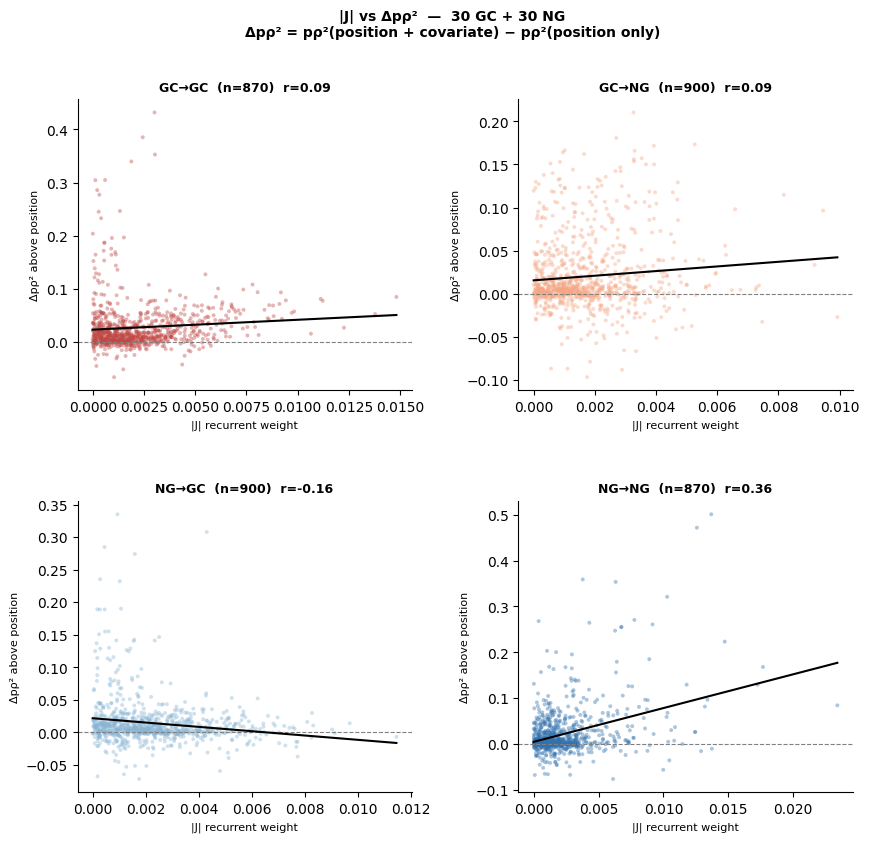

In [47]:
import sys, os, time
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/GRID-PATTERN-FORMATION')
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
os.environ['PYTHONWARNINGS'] = 'ignore'
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from spatial_manifolds.mlencoding import MLencoding

# ── Parameters ────────────────────────────────────────────────────────────────
N_GC        = 30
N_NG        = 30
N_BATCHES   = 30
N_CV        = 3
WINDOW_MS   = 20
HISTORY_MS  = 200
N_FILTERS   = 5
GRID_THRESH = 0.3

# ── Cell subset ───────────────────────────────────────────────────────────────
gc_subset  = grid_idx[:N_GC]
ng_subset  = nongrid_idx[:N_NG]
all_subset = np.concatenate([gc_subset, ng_subset])
is_gc_cell = np.array([True]*N_GC + [False]*N_NG)
N_CELLS    = len(all_subset)
print(f'Subset: {N_GC} GC + {N_NG} NG = {N_CELLS} cells')

# ── Collect activations ───────────────────────────────────────────────────────
g_list, pos_list = [], []
model.eval()
with torch.no_grad():
    for _ in tqdm(range(N_BATCHES), desc='Collecting activations'):
        inputs_b, pos_b, _ = trajectory_generator.get_test_batch()
        g_b = model.g(inputs_b).cpu().numpy()
        p_b = pos_b.cpu().numpy()
        g_b = g_b.transpose(1, 0, 2).reshape(-1, options.Ng)
        p_b = p_b.transpose(1, 0, 2).reshape(-1, 2)
        g_list.append(g_b[:, all_subset])
        pos_list.append(p_b)

G   = np.concatenate(g_list,   axis=0).astype(np.float32)
POS = np.concatenate(pos_list, axis=0).astype(np.float32)
pos_n = (POS - POS.min(0)) / (POS.max(0) - POS.min(0) + 1e-8)
x_pos = pos_n
T = len(G)
print(f'T={T:,} bins  ({T*0.02/60:.1f} min of trajectory)')

# ── XGBoost setup ─────────────────────────────────────────────────────────────
xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                  window=WINDOW_MS, n_filters=N_FILTERS, max_time=HISTORY_MS)

# ── Benchmark: estimate runtime before committing ─────────────────────────────
N_BENCH = 5
t0 = time.time()
y_bench = G[:, 0]
xgb.fit_cv(x_pos, y_bench, verbose=0, continuous_folds=True, n_cv=N_CV)
for ci in range(N_BENCH):
    xgb.fit_cv(np.column_stack([x_pos, G[:, ci + 1]]),
               y_bench, verbose=0, continuous_folds=True, n_cv=N_CV)
t_per_target = (time.time() - t0)          # time for 1 baseline + N_BENCH covariates
t_per_target *= (N_CELLS - 1) / N_BENCH   # scale to full N_CELLS-1 covariates
total_s = t_per_target * N_CELLS
print(f'Estimated runtime: {total_s/60:.1f} min  ({total_s:.0f}s total)')

# ── Pairwise XGBoost ──────────────────────────────────────────────────────────
pr2_mat = np.full((N_CELLS, N_CELLS), np.nan)

t_start = time.time()
for ti in tqdm(range(N_CELLS), desc='XGBoost'):
    y = G[:, ti]
    _, pr2_pos = xgb.fit_cv(x_pos, y, verbose=0, continuous_folds=True, n_cv=N_CV)
    pr2_pos_m  = float(np.nanmean(pr2_pos))
    for ci in range(N_CELLS):
        if ci == ti:
            continue
        x_full = np.column_stack([x_pos, G[:, ci]])
        _, pr2_full = xgb.fit_cv(x_full, y, verbose=0, continuous_folds=True, n_cv=N_CV)
        pr2_mat[ci, ti] = float(np.nanmean(pr2_full)) - pr2_pos_m

print(f'Done in {(time.time()-t_start)/60:.1f} min   Max Δpρ²={np.nanmax(pr2_mat):.4f}')

# ── |J| for the subset ────────────────────────────────────────────────────────
J     = model.RNN.weight_hh_l0.detach().cpu().numpy()
J_sub = np.abs(J[np.ix_(all_subset, all_subset)])

# ── Build pair list ───────────────────────────────────────────────────────────
J_vals, dpr2_vals, conn_types = [], [], []
for i in range(N_CELLS):
    for j in range(N_CELLS):
        if i == j or np.isnan(pr2_mat[j, i]):
            continue
        J_vals.append(J_sub[i, j])
        dpr2_vals.append(pr2_mat[j, i])
        ct = ('GC' if is_gc_cell[j] else 'NG') + '→' + ('GC' if is_gc_cell[i] else 'NG')
        conn_types.append(ct)

J_vals     = np.array(J_vals)
dpr2_vals  = np.array(dpr2_vals)
conn_types = np.array(conn_types)

# ── Figure ────────────────────────────────────────────────────────────────────
TYPE_ORDER = ['GC→GC', 'GC→NG', 'NG→GC', 'NG→NG']
COLORS     = {'GC→GC': '#c04744', 'GC→NG': '#f4a582',
               'NG→GC': '#88b4d4', 'NG→NG': '#3171ae'}

fig, axes = plt.subplots(2, 2, figsize=(10, 9),
                          gridspec_kw={'hspace': 0.38, 'wspace': 0.32})
for ax, ct in zip(axes.ravel(), TYPE_ORDER):
    mask = conn_types == ct
    jv, dv = J_vals[mask], dpr2_vals[mask]
    ax.scatter(jv, dv, s=8, alpha=0.4, color=COLORS[ct], edgecolors='none')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    if mask.sum() > 2:
        r = np.corrcoef(jv, dv)[0, 1]
        m, b = np.polyfit(jv, dv, 1)
        xr = np.linspace(jv.min(), jv.max(), 100)
        ax.plot(xr, m*xr + b, 'k-', lw=1.5)
        ax.set_title(f'{ct}  (n={mask.sum():,})  r={r:.2f}', fontsize=9, fontweight='bold')
    else:
        ax.set_title(f'{ct}  (n={mask.sum()})', fontsize=9, fontweight='bold')
    ax.set_xlabel('|J| recurrent weight', fontsize=8)
    ax.set_ylabel('Δpρ² above position',  fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'|J| vs Δpρ²  —  {N_GC} GC + {N_NG} NG\n'
              'Δpρ² = pρ²(position + covariate) − pρ²(position only)',
              fontsize=10, fontweight='bold')
plt.show()


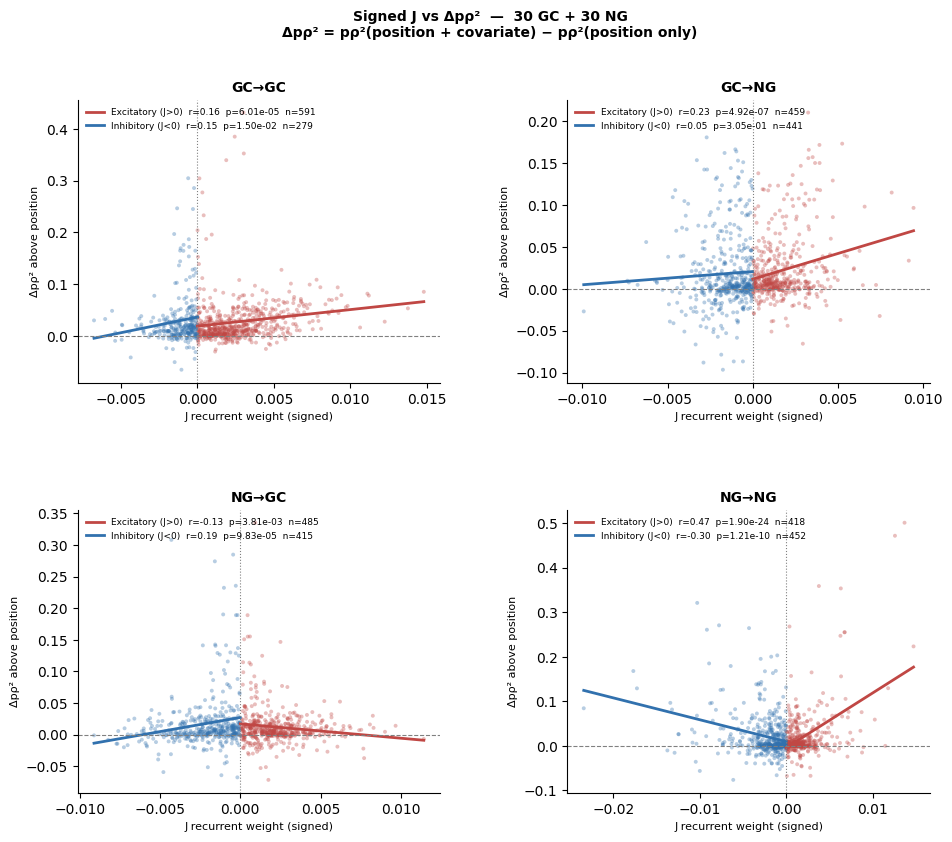

In [ ]:
import scipy.stats

# ── Signed J for the subset (not absolute — keeps excitatory/inhibitory split) ─
J     = model.RNN.weight_hh_l0.detach().cpu().numpy()
J_sub = J[np.ix_(all_subset, all_subset)]   # signed

# ── Build pair list ────────────────────────────────────────────────────────────
J_vals, dpr2_vals, conn_types, weight_signs = [], [], [], []
for i in range(N_CELLS):
    for j in range(N_CELLS):
        if i == j or np.isnan(pr2_mat[j, i]):
            continue
        J_vals.append(J_sub[i, j])
        dpr2_vals.append(pr2_mat[j, i])
        ct = ('GC' if is_gc_cell[j] else 'NG') + '→' + ('GC' if is_gc_cell[i] else 'NG')
        conn_types.append(ct)
        weight_signs.append('excitatory' if J_sub[i, j] >= 0 else 'inhibitory')

J_vals       = np.array(J_vals)
dpr2_vals    = np.array(dpr2_vals)
conn_types   = np.array(conn_types)
weight_signs = np.array(weight_signs)

# ── Figure: 2×2 by cell type, each split by weight sign ───────────────────────
TYPE_ORDER = ['GC→GC', 'GC→NG', 'NG→GC', 'NG→NG']

EXC_COL = '#c04744'   # excitatory
INH_COL = '#3171ae'   # inhibitory

fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

for ax, ct in zip(axes.ravel(), TYPE_ORDER):
    ct_mask = conn_types == ct

    for sign, col, label in [('excitatory', EXC_COL, 'Excitatory (J>0)'),
                               ('inhibitory', INH_COL, 'Inhibitory (J<0)')]:
        mask = ct_mask & (weight_signs == sign)
        jv   = J_vals[mask]
        dv   = dpr2_vals[mask]

        ax.scatter(jv, dv, s=8, alpha=0.35, color=col, edgecolors='none',
                   label=f'_{label}')   # leading _ suppresses from legend

        if mask.sum() > 2:
            r, p = scipy.stats.pearsonr(jv, dv)
            m, b = np.polyfit(jv, dv, 1)
            xr   = np.linspace(jv.min(), jv.max(), 100)
            ax.plot(xr, m*xr + b, color=col, lw=2,
                    label=f'{label}  r={r:.2f}  p={p:.2e}  n={mask.sum()}')

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(ct, fontsize=10, fontweight='bold')
    ax.set_xlabel('J recurrent weight (signed)', fontsize=8)
    ax.set_ylabel('Δpρ² above position', fontsize=8)
    ax.legend(fontsize=6.5, frameon=False, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Signed J vs Δpρ²  —  {N_GC} GC + {N_NG} NG\n'
              'Δpρ² = pρ²(position + covariate) − pρ²(position only)',
              fontsize=10, fontweight='bold')
plt.show()


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



── excitatory ──
           Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept  0.008    0.004   1.835  0.067  -0.001  0.016
J_raw      6.910    0.378  18.289  0.000   6.169  7.650
Group Var  0.001    0.006                              

── inhibitory ──
            Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept   0.012    0.004   3.054  0.002   0.004   0.020
J_raw      -2.788    0.422  -6.603  0.000  -3.615  -1.960
Group Var   0.001    0.005                               


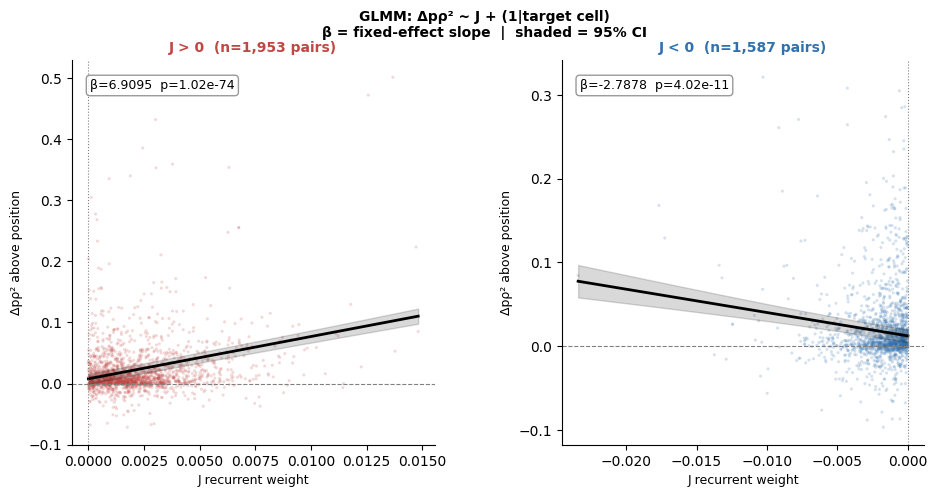

In [52]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

# ── Rebuild pair list with cell IDs ───────────────────────────────────────────
J     = model.RNN.weight_hh_l0.detach().cpu().numpy()
J_sub = J[np.ix_(all_subset, all_subset)]

rows = []
for i in range(N_CELLS):
    for j in range(N_CELLS):
        if i == j or np.isnan(pr2_mat[j, i]):
            continue
        rows.append({
            'delta_pr2' : float(pr2_mat[j, i]),
            'J_raw'     : float(J_sub[i, j]),
            'target_id' : str(i),
            'source_id' : str(j),
            'sign'      : 'excitatory' if J_sub[i, j] >= 0 else 'inhibitory',
        })

df = pd.DataFrame(rows)

# ── Fit GLMM: delta_pr2 ~ J_raw + (1|target_id) ──────────────────────────────
results = {}
for sign in ['excitatory', 'inhibitory']:
    sub  = df[df['sign'] == sign].copy()
    md   = smf.mixedlm("delta_pr2 ~ J_raw", sub, groups=sub["target_id"])
    fit  = md.fit(reml=True, method='lbfgs')
    results[sign] = fit
    print(f'\n── {sign} ──')
    print(fit.summary().tables[1])

# ── Figure ────────────────────────────────────────────────────────────────────
PANELS = [('excitatory', 'J > 0', '#c04744'),
          ('inhibitory', 'J < 0', '#3171ae')]

fig, axes = plt.subplots(1, 2, figsize=(11, 5),
                          gridspec_kw={'wspace': 0.35})

for ax, (sign, sign_label, col) in zip(axes, PANELS):
    sub    = df[df['sign'] == sign]
    jv     = sub['J_raw'].values
    dv     = sub['delta_pr2'].values
    fit    = results[sign]

    ax.scatter(jv, dv, s=5, alpha=0.2, color=col, edgecolors='none',
               rasterized=True)

    x_line = np.linspace(jv.min(), jv.max(), 300)
    b0     = fit.params['Intercept']
    b1     = fit.params['J_raw']
    y_line = b0 + b1 * x_line

    cov_fe  = fit.cov_params().loc[['Intercept', 'J_raw'],
                                    ['Intercept', 'J_raw']].values
    X_line  = np.column_stack([np.ones_like(x_line), x_line])
    se_line = np.sqrt((X_line @ cov_fe * X_line).sum(axis=1))
    t_crit  = scipy.stats.t.ppf(0.975, df=len(sub) - 2)

    ax.plot(x_line, y_line, 'k-', lw=2)
    ax.fill_between(x_line,
                    y_line - t_crit * se_line,
                    y_line + t_crit * se_line,
                    color='k', alpha=0.15)

    p_val = fit.pvalues['J_raw']
    coef  = fit.params['J_raw']
    p_str = f'p={p_val:.2e}' if p_val >= 1e-300 else 'p<1e-300'
    ax.text(0.05, 0.95, f'β={coef:.4f}  {p_str}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel('J recurrent weight', fontsize=9)
    ax.set_ylabel('Δpρ² above position', fontsize=9)
    ax.set_title(f'{sign_label}  (n={len(sub):,} pairs)', fontsize=10,
                  fontweight='bold', color=col)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('GLMM: Δpρ² ~ J + (1|target cell)\n'
             'β = fixed-effect slope  |  shaded = 95% CI',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


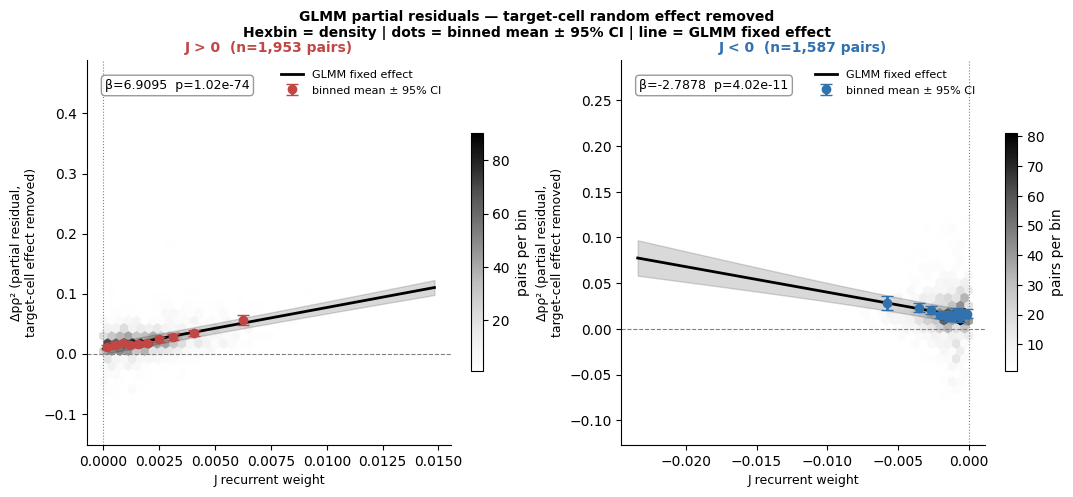

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.35})

PANELS = [('excitatory', 'J > 0', '#c04744'),
          ('inhibitory', 'J < 0', '#3171ae')]

N_BINS = 10   # quantile bins along x

for ax, (sign, sign_label, col) in zip(axes, PANELS):
    sub = df[df['sign'] == sign].copy()
    fit = results[sign]

    # ── Partial residuals: remove target-cell random intercept ────────────────
    re = {k: float(v.iloc[0]) for k, v in fit.random_effects.items()}
    sub['re']          = sub['target_id'].map(re)
    sub['partial_y']   = sub['delta_pr2'] - sub['re']

    jv = sub['J_raw'].values
    py = sub['partial_y'].values

    # ── Hexbin for density ────────────────────────────────────────────────────
    hb = ax.hexbin(jv, py, gridsize=40, cmap='Greys', mincnt=1,
                   linewidths=0.2)
    plt.colorbar(hb, ax=ax, label='pairs per bin', fraction=0.03)

    # ── Binned means ± 95% CI ─────────────────────────────────────────────────
    bin_edges  = np.quantile(jv, np.linspace(0, 1, N_BINS + 1))
    bin_idx    = np.digitize(jv, bin_edges[1:-1])
    bin_means, bin_cis, bin_x = [], [], []
    for b in range(N_BINS):
        vals = py[bin_idx == b]
        if len(vals) < 3:
            continue
        m  = vals.mean()
        se = vals.std() / np.sqrt(len(vals))
        tc = scipy.stats.t.ppf(0.975, df=len(vals) - 1)
        bin_means.append(m)
        bin_cis.append(tc * se)
        bin_x.append(np.median(jv[bin_idx == b]))

    ax.errorbar(bin_x, bin_means, yerr=bin_cis,
                fmt='o', color=col, ms=6, lw=2, capsize=4,
                zorder=5, label='binned mean ± 95% CI')

    # ── GLMM fixed-effect line ────────────────────────────────────────────────
    x_line = np.linspace(jv.min(), jv.max(), 300)
    b0, b1 = fit.params['Intercept'], fit.params['J_raw']
    y_line = b0 + b1 * x_line

    cov_fe  = fit.cov_params().loc[['Intercept','J_raw'],
                                    ['Intercept','J_raw']].values
    X_line  = np.column_stack([np.ones_like(x_line), x_line])
    se_line = np.sqrt((X_line @ cov_fe * X_line).sum(axis=1))
    t_crit  = scipy.stats.t.ppf(0.975, df=len(sub) - 2)

    ax.plot(x_line, y_line, 'k-', lw=2, label='GLMM fixed effect')
    ax.fill_between(x_line,
                    y_line - t_crit * se_line,
                    y_line + t_crit * se_line,
                    color='k', alpha=0.15)

    p_val = fit.pvalues['J_raw']
    ax.text(0.05, 0.95,
            f"β={fit.params['J_raw']:.4f}  p={p_val:.2e}",
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel('J recurrent weight', fontsize=9)
    ax.set_ylabel('Δpρ² (partial residual,\ntarget-cell effect removed)', fontsize=9)
    ax.set_title(f'{sign_label}  (n={len(sub):,} pairs)', fontsize=10,
                  fontweight='bold', color=col)
    ax.legend(fontsize=8, frameon=False, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('GLMM partial residuals — target-cell random effect removed\n'
             'Hexbin = density | dots = binned mean ± 95% CI | line = GLMM fixed effect',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


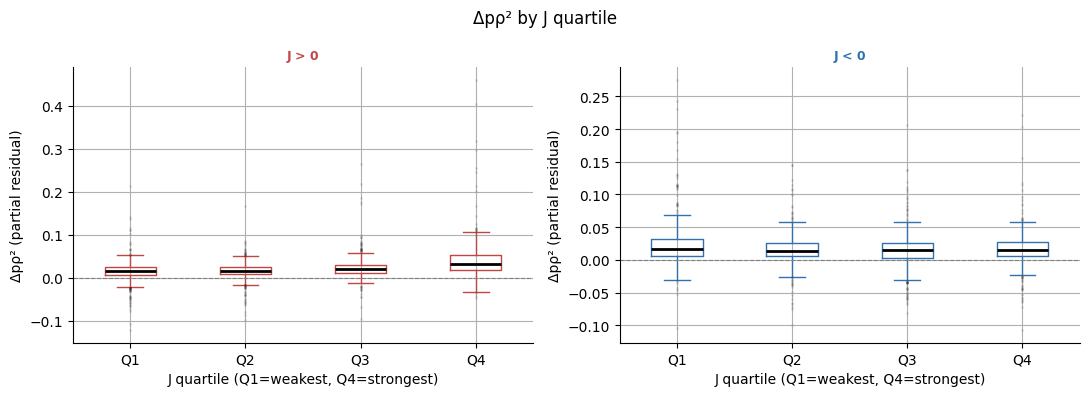

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (sign, sign_label, col) in zip(axes, PANELS):
    sub  = df[df['sign'] == sign].copy()
    sub['re']        = sub['target_id'].map({k: float(v.iloc[0]) for k,v in results[sign].random_effects.items()})
    sub['partial_y'] = sub['delta_pr2'] - sub['re']
    sub['quartile']  = pd.qcut(sub['J_raw'], 4, labels=['Q1','Q2','Q3','Q4'])
    sub.boxplot(column='partial_y', by='quartile', ax=ax,
                boxprops=dict(color=col), medianprops=dict(color='k', lw=2),
                whiskerprops=dict(color=col), capprops=dict(color=col),
                flierprops=dict(marker='.', alpha=0.1, color=col, ms=2))
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    ax.set_title(f'{sign_label}', fontsize=9, fontweight='bold', color=col)
    ax.set_xlabel('J quartile (Q1=weakest, Q4=strongest)')
    ax.set_ylabel('Δpρ² (partial residual)')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Δpρ² by J quartile'); plt.tight_layout(); plt.show()


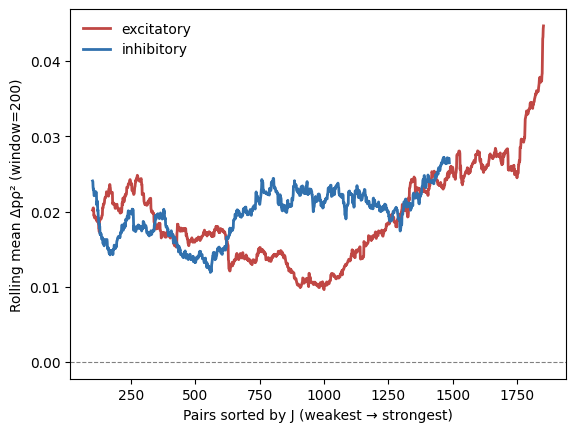

In [55]:
for sign, col in [('excitatory','#c04744'), ('inhibitory','#3171ae')]:
    sub  = df[df['sign'] == sign].sort_values('J_raw').copy()
    roll = sub['delta_pr2'].rolling(200, center=True).mean()
    plt.plot(np.arange(len(sub)), roll, color=col, lw=2, label=sign)
plt.axhline(0, color='grey', ls='--', lw=0.8)
plt.xlabel('Pairs sorted by J (weakest → strongest)')
plt.ylabel('Rolling mean Δpρ² (window=200)')
plt.legend(frameon=False); plt.show()


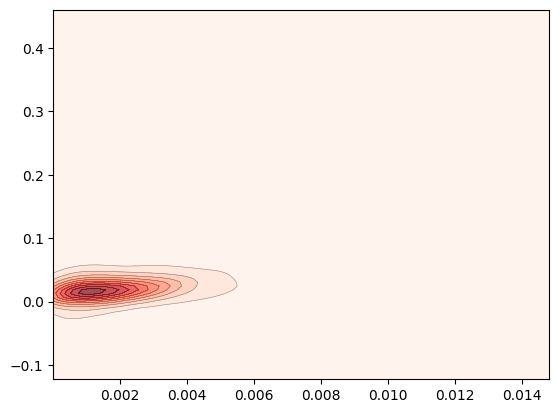

In [57]:
# Run this once after fitting the GLMMs
re_exc = {k: float(v.iloc[0]) for k, v in results['excitatory'].random_effects.items()}
re_inh = {k: float(v.iloc[0]) for k, v in results['inhibitory'].random_effects.items()}

def get_re(row):
    re_dict = re_exc if row['sign'] == 'excitatory' else re_inh
    return re_dict.get(row['target_id'], 0.0)

df['re']        = df.apply(get_re, axis=1)
df['partial_y'] = df['delta_pr2'] - df['re']

import scipy.stats as st
# For one panel:
sub = df[df['sign']=='excitatory']
xv, yv = sub['J_raw'].values, sub['partial_y'].values
kde = st.gaussian_kde([xv, yv])
xi, yi = np.mgrid[xv.min():xv.max():100j, yv.min():yv.max():100j]
zi = kde([xi.ravel(), yi.ravel()]).reshape(xi.shape)
plt.contourf(xi, yi, zi, levels=10, cmap='Reds', alpha=0.7)
plt.contour(xi, yi, zi, levels=10, colors='k', linewidths=0.4, alpha=0.4)


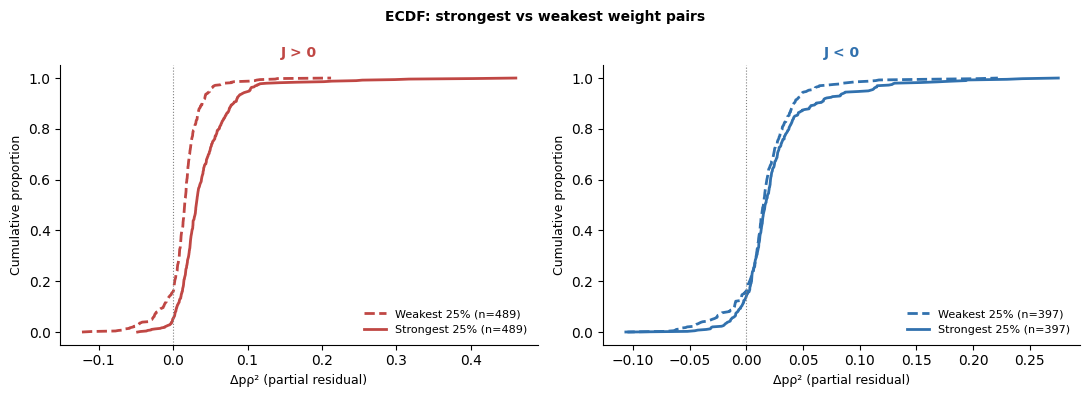

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (sign, sign_label, col) in zip(axes, PANELS):
    sub = df[df['sign'] == sign].copy()
    q25 = sub['J_raw'].abs().quantile(0.25)
    q75 = sub['J_raw'].abs().quantile(0.75)
    weak   = sub[sub['J_raw'].abs() <= q25]['partial_y'].sort_values()
    strong = sub[sub['J_raw'].abs() >= q75]['partial_y'].sort_values()
    for vals, label, ls in [(weak, 'Weakest 25%', '--'), (strong, 'Strongest 25%', '-')]:
        ax.plot(vals, np.linspace(0, 1, len(vals)), lw=2, ls=ls,
                color=col, label=f'{label} (n={len(vals)})')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel('Δpρ² (partial residual)', fontsize=9)
    ax.set_ylabel('Cumulative proportion', fontsize=9)
    ax.set_title(f'{sign_label}', fontsize=10, fontweight='bold', color=col)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('ECDF: strongest vs weakest weight pairs', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: T

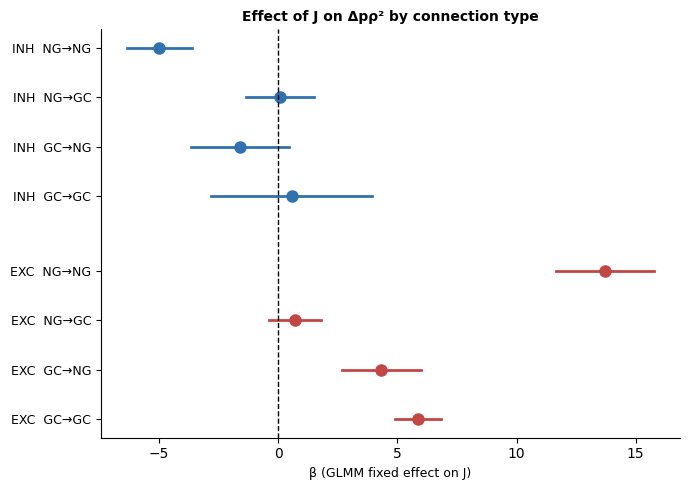

In [60]:
import statsmodels.formula.api as smf
rows = []
for i in range(N_CELLS):
    for j in range(N_CELLS):
        if i == j or np.isnan(pr2_mat[j, i]):
            continue
        rows.append({
            'delta_pr2' : float(pr2_mat[j, i]),
            'J_raw'     : float(J_sub[i, j]),
            'target_id' : str(i),
            'source_id' : str(j),
            'sign'      : 'excitatory' if J_sub[i, j] >= 0 else 'inhibitory',
            'conn_type' : ('GC' if is_gc_cell[j] else 'NG') + '→' +
                          ('GC' if is_gc_cell[i] else 'NG'),
        })

df = pd.DataFrame(rows)


types  = ['GC→GC', 'GC→NG', 'NG→GC', 'NG→NG']
signs  = ['excitatory', 'inhibitory']
colors = {'excitatory': '#c04744', 'inhibitory': '#3171ae'}

fig, ax = plt.subplots(figsize=(7, 5))
y_pos = 0
yticks, ylabels = [], []

for sign in signs:
    for ct in types:
        sub = df[(df['sign'] == sign) & (df['conn_type'] == ct)]
        if len(sub) < 10:
            continue
        fit = smf.mixedlm("delta_pr2 ~ J_raw", sub,
                           groups=sub["target_id"]).fit(reml=True, method='lbfgs',
                                                         disp=False)
        b  = fit.params['J_raw']
        ci = fit.conf_int().loc['J_raw']
        col = colors[sign]
        ax.plot([ci[0], ci[1]], [y_pos, y_pos], color=col, lw=2)
        ax.plot(b, y_pos, 'o', color=col, ms=8)
        yticks.append(y_pos); ylabels.append(f'{sign[:3].upper()}  {ct}')
        y_pos += 1
    y_pos += 0.5  # gap between sign groups

ax.axvline(0, color='k', lw=1, ls='--')
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel('β (GLMM fixed effect on J)', fontsize=9)
ax.set_title('Effect of J on Δpρ² by connection type', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


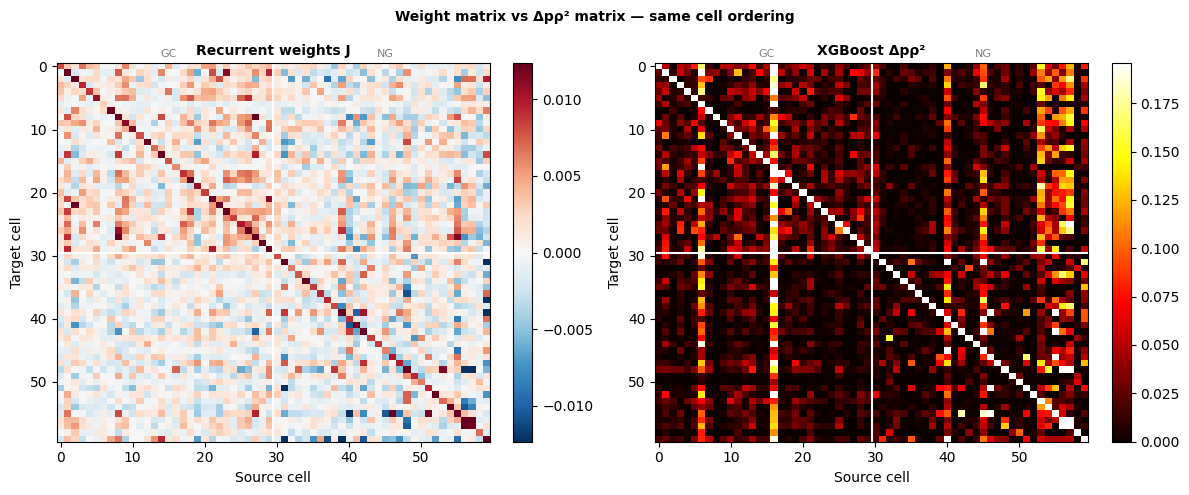

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order_plot = np.concatenate([grid_idx[:N_GC], nongrid_idx[:N_NG]])
J_plot     = J[np.ix_(order_plot, order_plot)]
pr2_plot   = pr2_mat.copy()   # already in subset order

for ax, mat, title, cmap in [
    (axes[0], J_plot,   'Recurrent weights J', 'RdBu_r'),
    (axes[1], pr2_plot, 'XGBoost Δpρ²',        'hot')]:
    vmax = np.nanpercentile(np.abs(mat), 99)
    im = ax.imshow(mat, cmap=cmap, vmin=-vmax if cmap=='RdBu_r' else 0,
                    vmax=vmax, aspect='auto', interpolation='nearest')
    ax.axhline(N_GC - 0.5, color='white', lw=1.5)
    ax.axvline(N_GC - 0.5, color='white', lw=1.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Source cell'); ax.set_ylabel('Target cell')
    plt.colorbar(im, ax=ax, fraction=0.04)
    for pos in [N_GC/2, N_GC + N_NG/2]:
        label = 'GC' if pos < N_GC else 'NG'
        ax.text(pos, -1.5, label, ha='center', fontsize=8, color='grey')

plt.suptitle('Weight matrix vs Δpρ² matrix — same cell ordering',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


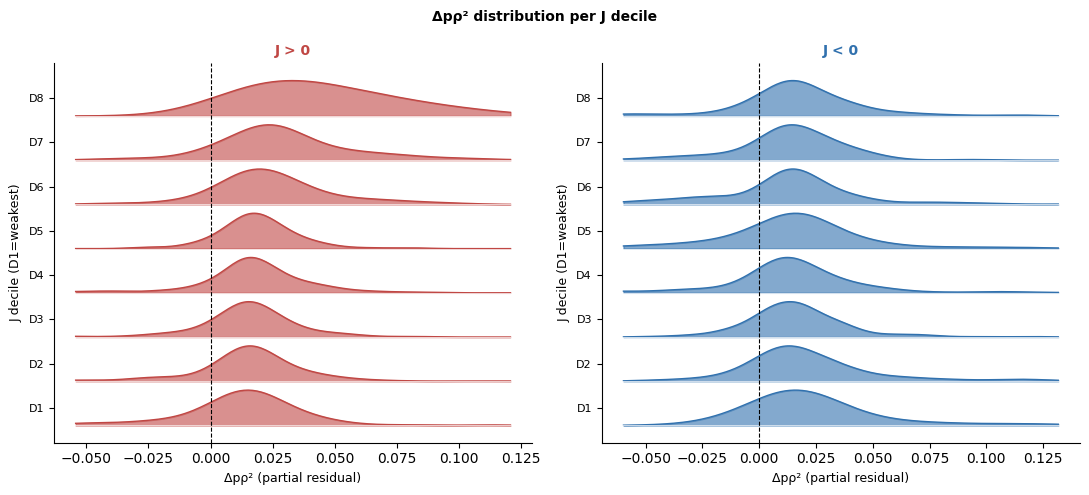

In [63]:
from matplotlib.collections import PolyCollection
re_exc = {k: float(v.iloc[0]) for k, v in results['excitatory'].random_effects.items()}
re_inh = {k: float(v.iloc[0]) for k, v in results['inhibitory'].random_effects.items()}

def get_re(row):
    re_dict = re_exc if row['sign'] == 'excitatory' else re_inh
    return re_dict.get(row['target_id'], 0.0)

df['re']        = df.apply(get_re, axis=1)
df['partial_y'] = df['delta_pr2'] - df['re']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
N_DEC = 8

for ax, (sign, sign_label, col) in zip(axes, PANELS):
    sub  = df[df['sign'] == sign].copy()
    sub['decile'] = pd.qcut(sub['J_raw'], N_DEC, labels=False)
    xlim = np.nanpercentile(sub['partial_y'], [1, 99])

    for d in range(N_DEC):
        vals = sub[sub['decile'] == d]['partial_y'].dropna()
        kde  = scipy.stats.gaussian_kde(vals)
        x    = np.linspace(*xlim, 200)
        y    = kde(x)
        y    = y / y.max() * 0.8   # normalise height
        ax.fill_between(x, d + y, d, alpha=0.6, color=col)
        ax.plot(x, d + y, color=col, lw=1)
        ax.axhline(d, color='white', lw=0.5)

    ax.set_yticks(np.arange(N_DEC) + 0.4)
    ax.set_yticklabels([f'D{d+1}' for d in range(N_DEC)], fontsize=8)
    ax.set_xlabel('Δpρ² (partial residual)', fontsize=9)
    ax.set_ylabel('J decile (D1=weakest)', fontsize=9)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_title(f'{sign_label}', fontsize=10, fontweight='bold', color=col)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Δpρ² distribution per J decile', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


# Manifold distance

In [ ]:
# Keeping all grid cells
origins = np.stack(np.mgrid[:3, :3] - 1) * res // 4 + res // 2

fig = plt.figure(figsize=(8, 8))
for i in range(3):
    for j in range(3):
        plt.subplot(3, 3, 3 * i + j + 1)
        origin_idx = np.ravel_multi_index((origins[0, i, j], origins[1, i, j]), (res, res))
        r0   = rate_map[:, origin_idx, None]
        dists = np.linalg.norm(r0 - rate_map, axis=0)
        im   = plt.imshow(dists.reshape(res, res) / np.max(dists),
                          cmap='viridis_r', interpolation='gaussian')
        plt.axis('off')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.12, 0.02, 0.74])
cbar    = fig.colorbar(im, cax=cbar_ax)
cbar.ax.locator_params(nbins=3)
cbar.ax.tick_params(labelsize=20)
cbar.outline.set_visible(False)

In [ ]:
# Keeping only top grid cells
n_grid_cells = min(500, Ng)
grid_sort    = np.flip(np.argsort(score_60))
origins      = np.stack(np.mgrid[:3, :3] - 1) * res // 4 + res // 2

fig = plt.figure(figsize=(8, 8))
for i in range(3):
    for j in range(3):
        plt.subplot(3, 3, 3 * i + j + 1)
        origin_idx = np.ravel_multi_index((origins[0, i, j], origins[1, i, j]), (res, res))
        r0    = rate_map[grid_sort[:n_grid_cells], origin_idx, None]
        dists = np.linalg.norm(r0 - rate_map[grid_sort[:n_grid_cells]], axis=0)
        im    = plt.imshow(dists.reshape(res, res) / np.max(dists),
                           cmap='viridis_r', interpolation='gaussian')
        plt.axis('off')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.12, 0.02, 0.74])
cbar    = fig.colorbar(im, cax=cbar_ax)
cbar.ax.locator_params(nbins=3)
cbar.ax.tick_params(labelsize=20)
cbar.outline.set_visible(False)

# Neural sheet

In [ ]:
# Fourier transform of rate maps
rm_fft_real = np.zeros([Ng, res, res])
rm_fft_imag = np.zeros([Ng, res, res])

for i in tqdm(range(Ng)):
    rm_fft_real[i] = np.real(np.fft.fft2(rate_map[i].reshape([res, res])))
    rm_fft_imag[i] = np.imag(np.fft.fft2(rate_map[i].reshape([res, res])))

rm_fft = rm_fft_real + 1j * rm_fft_imag

In [ ]:
width = 6
idxs  = np.arange(-width + 1, width)
x2, y2 = np.meshgrid(np.arange(2 * width - 1), np.arange(2 * width - 1))
im    = (np.real(rm_fft) ** 2).mean(0)
im[0, 0] = 0
plt.scatter(x2, y2, c=im[idxs][:, idxs], s=300, cmap='Oranges')
plt.axis('equal')
plt.axis('off')
plt.title('Mean power')

In [ ]:
# Identify dominant Fourier modes (tune k1, k2, k3 to match the power spectrum above)
k1 = [3, 0]
k2 = [2, 3]
k3 = [-1, 3]

freq = 1
ks   = freq * np.array([k1, k2, k3, k1, k1, k1]).astype('int')
modes = np.stack([rm_fft[:, k[0], k[1]] for k in ks])

In [ ]:
# Find phases
phases = [np.angle(mode) for mode in modes]

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.scatter(phases[0], phases[1], c='black', s=10)
plt.xlabel(r'$\phi_1$'); plt.ylabel(r'$\phi_2$')
plt.subplot(132)
plt.scatter(phases[1], phases[2], c='black', s=10)
plt.xlabel(r'$\phi_2$'); plt.ylabel(r'$\phi_3$')
plt.subplot(133)
plt.scatter(phases[0], phases[2], c='black', s=10)
plt.xlabel(r'$\phi_1$'); plt.ylabel(r'$\phi_3$')
plt.show()

In [ ]:
fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(phases[0], phases[1], phases[2], c='black', s=2)
ax.view_init(azim=60)
ax.xaxis.set_pane_color((1., 1., 1., 0.))
ax.yaxis.set_pane_color((1., 1., 1., 0.))
ax.zaxis.set_pane_color((1., 1., 1., 0.))
ax.xaxis._axinfo['grid']['color'] = (1, 1, 1, 0)
ax.yaxis._axinfo['grid']['color'] = (1, 1, 1, 0)
ax.zaxis._axinfo['grid']['color'] = (1, 1, 1, 0)
ax.set_xlabel(r'$\phi_1$'); ax.set_ylabel(r'$\phi_2$'); ax.set_zlabel(r'$\phi_3$')

In [ ]:
freq  = 1
cmaps = ['Blues', 'Oranges', 'Greens']
x     = np.mgrid[:res, :res] * 2 * np.pi / res
x     = x.reshape(2, -1)
k     = freq * np.stack([k1, k2, k3])
X     = np.concatenate([np.cos(k.dot(x)), np.sin(k.dot(x))], axis=0)
idxs1, idxs2 = np.mgrid[:res, :res]
idxs  = np.ravel_multi_index((idxs1, idxs2), (res, res)).ravel()

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    B    = np.stack([np.cos(phases[i]), np.sin(phases[i])])
    test = B @ rate_map
    plt.scatter(test[0], test[1], c=X[i][idxs], cmap=cmaps[i], s=20)
    plt.axis('off')

In [ ]:
from utils import get_2d_sort

N  = rate_map.shape[0]
n  = int(np.sqrt(N))
width = int(np.sqrt(N))
X2, Y2 = np.meshgrid(np.arange(width), np.arange(width))
X2 = X2 * 2 * np.pi / width
Y2 = Y2 * 2 * np.pi / width

s1 = np.zeros(phases[0].shape)
s2 = np.zeros(phases[0].shape)
fac = np.sqrt(3) / 2

for i in range(Ng):
    penalty_1 = np.cos(freq * X2 - phases[0][i] / fac)
    penalty_2 = np.cos(freq * Y2 - phases[2][i] / fac)
    penalty_3 = np.cos(freq * (X2 + Y2) - phases[1][i] / fac)
    ind = np.argmax(penalty_1 + penalty_2 + penalty_3 + np.random.randn() / 100)
    s1[i], s2[i] = np.unravel_index([ind], penalty_1.shape)

total_order    = get_2d_sort(s1, s2)
rm_sort_square = rate_map[total_order.ravel()].reshape([n, n, -1])

In [ ]:
# Skew matrix to transform parallelogram unit cells to squares
A    = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 4
Ainv = np.linalg.inv(A)

freq   = 2
nplots = 10
fig, axes = plt.subplots(nplots, nplots, figsize=(16, 16))
for i in range(nplots):
    for j in range(nplots):
        idx = np.ravel_multi_index(((i + nplots // 2) * res // nplots // freq,
                                    (j + nplots // 2) * res // nplots // freq), (res, res))
        im  = rm_sort_square[:, :, idx]
        im  = scipy.ndimage.affine_transform(im, Ainv, mode='wrap')
        im  = scipy.ndimage.gaussian_filter(im, sigma=(2, 2))
        axes[j, i].imshow(im.T, cmap='jet')
        axes[j, i].axis('off')

# Connectivity

In [ ]:
# Recurrent weight matrix J  (weight_hh_l0 in PyTorch)
J = model.RNN.weight_hh_l0.detach().cpu().numpy()   # (Ng, Ng)
plt.figure(figsize=(6, 6))
plt.imshow(J, cmap='RdBu')
plt.title('J')

In [ ]:
# Eigenvalues
eigs, eigvs = np.linalg.eig(J)

fig, ax = plt.subplots()
plt.scatter(np.real(eigs), np.imag(eigs), c='black', s=20)
plt.scatter(np.real(eigs[:9]), np.imag(eigs[:9]), c='C1', s=20)
circle1 = plt.Circle((0, 0), 1, color='tan', fill=False,
                      linestyle='dashed', linewidth=2)
ax.add_artist(circle1)
plt.xlim([-1.1, 2.5]); plt.ylim([-1.1, 1.1])
plt.gca().set_aspect('equal', adjustable='box')
plt.locator_params(nbins=4)

In [ ]:
U_eig, S_eig, Vh_eig = np.linalg.svd(J)

plt.figure(figsize=(8, 4))
plt.plot(S_eig[:100], 'o-', c='black')
plt.plot(S_eig[:9],   'o-', c='C1')

In [ ]:
# Eigenvectors sorted by eigenvalue magnitude
eig_order = np.flip(np.argsort(np.abs(eigs)))

A    = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
Ainv = np.linalg.inv(A)

plt.figure(figsize=(16, 4))
for i in range(24):
    plt.subplot(2, 12, i + 1)
    idx = eig_order[i]
    im  = np.real(eigvs[total_order, idx].reshape(n, n))
    im  = scipy.ndimage.affine_transform(im, Ainv, mode='wrap')
    im  = scipy.ndimage.gaussian_filter(im, sigma=(2, 2))
    plt.imshow(im, cmap='coolwarm', interpolation='gaussian')
    plt.axis('off')

## Sort weights

In [ ]:
n      = int(np.sqrt(N))
Jsort  = J[total_order][:, total_order]
J_square = np.reshape(Jsort, (n, n, n, n))

Jmean = np.zeros([n, n])
for i in range(n):
    for j in range(n):
        Jmean += np.roll(np.roll(J_square[i, j], -i, axis=0), -j, axis=1)

Jmean[0, 0] = np.max(Jmean[1:, 1:])
Jmean = np.roll(np.roll(Jmean, n // 2, axis=0), n // 2, axis=1)

A    = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
Ainv = np.linalg.inv(A)
im   = scipy.ndimage.affine_transform(Jmean, Ainv, mode='wrap')
imroll = np.roll(np.roll(im, -n // 4, axis=0), 0, axis=1)

plt.figure(figsize=(5, 5))
plt.imshow(imroll, cmap='coolwarm')
plt.title('J (sorted)')
plt.axis('off')

In [ ]:
n     = int(np.sqrt(N))
width = 18
xs    = np.arange(2 * width - 1)
X3, Y3 = np.meshgrid(xs, xs)
XY    = np.stack((X3.ravel(), Y3.ravel()), 0)
T     = np.array([[1, 0.5], [0, np.sqrt(3) / 2]])
XY    = T.dot(XY)

idxs    = np.arange(-width + 1, width)
im_fft  = np.abs(np.fft.fft2(im))
im_fft[0, 0] = 0

plt.figure(figsize=(10, 10))
plt.scatter(XY[0], XY[1], s=120, c=im_fft[idxs][:, idxs].ravel(),
            marker='h', cmap='viridis')
plt.axis('equal')
plt.axis('off')

# Path integration

Compute JGMv — how the recurrent matrix acts on velocity-driven activity.

In [ ]:
# J = recurrent weights, M = input weights  (PyTorch attribute names)
J = model.RNN.weight_hh_l0.detach().cpu().numpy()   # (Ng, Ng)
M = model.RNN.weight_ih_l0.detach().cpu().numpy()   # (Ng, 2)

theta = 0
v     = np.stack([np.cos(theta), np.sin(theta)])   # (2,)

G    = (J @ rate_map) > 0
Mv   = M @ v                    # (Ng,)
GMv  = G * Mv[:, None]          # (Ng, res²)
JGMv = J @ GMv                  # (Ng, res²)

# Compute sliding mode
shift = 5
SM    = rate_map.reshape(Ng, res, res)
SM    = np.roll(SM, shift=-shift, axis=1) - np.roll(SM, shift=shift, axis=1)
SM    = SM.reshape(Ng, -1)

# Projection and cosine angle (numpy, not TF)
proj    = np.sum(JGMv * SM, axis=0)
cos_ang = proj / np.sqrt((np.sum(SM ** 2, axis=0) * np.sum(JGMv ** 2, axis=0)) + 1e-12)

crop = 10
idxs1, idxs2 = np.mgrid[crop:res - crop, crop:res - crop]
crop_idxs    = np.ravel_multi_index((idxs1, idxs2), (res, res)).ravel()

plt.figure(figsize=(8, 5))
plt.hist(cos_ang[crop_idxs], bins=20, color='slategrey')
plt.xlim([0, 0.8])
plt.xlabel('Projection onto sliding mode')
plt.ylabel('Count')

In [ ]:
thetas     = np.linspace(0, 2 * np.pi, 8, endpoint=False)
clock_idxs = np.roll([0, 1, 2, 5, 8, 7, 6, 3], 1)
idx        = np.ravel_multi_index((20, 20), (res, res))

plt.figure(figsize=(9, 9))
for i in range(8):
    theta = thetas[i]
    v     = np.stack([np.cos(theta), np.sin(theta)])
    Mv    = M @ v
    GMv   = G[:, idx] * Mv
    JGMv  = J @ GMv

    plt.subplot(3, 3, clock_idxs[i] + 1)
    im2 = JGMv[total_order].reshape(n, n)
    im2 = scipy.ndimage.gaussian_filter(im2, (3, 3))
    plt.imshow(im2, cmap='RdBu')
    plt.axis('off')
plt.tight_layout()

# SVD

In [ ]:
X_svd = rate_map - rate_map.mean(-1, keepdims=True)
X_svd -= X_svd.mean(-1, keepdims=True)
Ua, S_svd, V_svd = scipy.linalg.svd(X_svd)
rm_embed = Ua.T @ rate_map

In [ ]:
# Construct torus — tune k1,k2,k3 to match the dominant Fourier modes above
k1t = [3, 0]; k2t = [2, 2.5]; k3t = [-1, 2.3]

freq  = 1
x_t   = np.mgrid[:res, :res] * 2 * np.pi / res
x_t   = x_t.reshape(2, -1)
k_t   = freq * np.stack([k1t, k2t, k3t])
X_t   = np.concatenate([np.cos(k_t.dot(x_t)), np.sin(k_t.dot(x_t))], axis=0)
cmaps_t = ['Blues', 'Oranges', 'Greens']

idxs1, idxs2 = np.mgrid[:res, :res]
idxs_t = np.ravel_multi_index((idxs1, idxs2), (res, res)).ravel()

# Find rotation
RM    = rm_embed[:10, idxs_t]
X_crop = X_t[:, idxs_t]
R     = np.linalg.inv(RM.dot(RM.T)).dot(RM).dot(X_crop.T).T

# Lowdin symmetric orthogonalization
U_r, s_r, V_r = np.linalg.svd(R)
S2    = U_r.dot(np.diag(1. / s_r)).dot(U_r.T)
R     = S2.dot(R)

# Plot rings
plt.figure(figsize=(12, 4))
for i in range(R.shape[0] // 2):
    plt.subplot(1, 3, i + 1)
    plt.scatter(R.dot(RM)[i], R.dot(RM)[i + 3], c=X_t[i][idxs_t], cmap=cmaps_t[i], s=10)
    plt.axis('off')

# Null model (low-pass filtered noise)

In [ ]:
# Construct filter
max_freq = 3; min_freq = 0
x_n, y_n = np.meshgrid(np.arange(res), np.arange(res))
r_n   = np.sqrt((x_n - res // 2) ** 2 + (y_n - res // 2) ** 2)
filt  = np.greater(max_freq - r_n, 0) * np.greater(r_n - min_freq, 0)

# Make random noise patterns
N_null = min(4096, Ng)
noise  = np.random.randn(N_null, res, res)

# Convolve with filter
noise_tilde      = np.fft.fftshift(np.fft.fft2(noise))
noise_tilde_filt = noise_tilde * filt
patterns         = np.real(np.fft.ifft2(np.fft.ifftshift(noise_tilde_filt)))

In [ ]:
# Fourier transform of noise patterns
rm_fft_null = np.zeros([N_null, res, res], dtype=complex)
for i in tqdm(range(N_null)):
    rm_fft_null[i] = np.fft.fft2(patterns[i].reshape([res, res]))

k1n = [3, 0]; k2n = [2, 3]; k3n = [-1, 3]
freq = 1
ks_n = freq * np.array([k1n, k2n, k3n, k1n, k1n, k1n]).astype('int')
modes_null  = np.stack([rm_fft_null[:, k[0], k[1]] for k in ks_n])
phases_null = [np.angle(mode) for mode in modes_null]

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(phases_null[0], phases_null[1], phases_null[2], c='black', s=10)
ax.view_init(azim=60)
ax.xaxis.set_pane_color((1., 1., 1., 0.))
ax.yaxis.set_pane_color((1., 1., 1., 0.))
ax.zaxis.set_pane_color((1., 1., 1., 0.))
ax.xaxis._axinfo['grid']['color'] = (1, 1, 1, 0)
ax.yaxis._axinfo['grid']['color'] = (1, 1, 1, 0)
ax.zaxis._axinfo['grid']['color'] = (1, 1, 1, 0)
ax.set_xlabel(r'$\phi_1$'); ax.set_ylabel(r'$\phi_2$'); ax.set_zlabel(r'$\phi_3$')
plt.title('Null model does not obey phase relationship')

# Boundary extension

Rate maps computed in a larger environment to test that grid fields tile beyond the training box.

In [ ]:
options.sequence_length = 80
options.box_width       = 4.4
options.box_height      = 4.4
trajectory_generator_big = TrajectoryGenerator(options, place_cells)

In [ ]:
res_big   = 50
n_avg_big = 10
activations_big, _, _, _ = compute_ratemaps(
    model, trajectory_generator_big, options,
    res=res_big, n_avg=n_avg_big, Ng=Ng)

n_plot = min(256, Ng)
plt.figure(figsize=(16, 4 * n_plot // 8 ** 2))
rm_fig = plot_ratemaps(activations_big, n_plot, smooth=True)
plt.imshow(rm_fig)
plt.axis('off')

# Reset
options.sequence_length = 20
options.box_width       = 2.2
options.box_height      = 2.2
trajectory_generator    = TrajectoryGenerator(options, place_cells)

# Head direction and speed tuning

In [ ]:
g_all  = []
vs_all = []
hds_all = []
n_avg_hd = 20

for index in tqdm(range(n_avg_hd), leave=False):
    inputs, pos_batch, _ = trajectory_generator.get_test_batch()
    v = inputs[0].cpu().numpy()          # (seq_len, batch, 2)
    g_batch = model.g(inputs).detach().cpu().numpy()

    vx, vy = v[:, :, 0], v[:, :, 1]
    speed  = np.sqrt(vx ** 2 + vy ** 2)
    hd     = np.arctan2(vy, vx)
    g_batch = g_batch.reshape(-1, Ng)

    g_all.append(g_batch)
    vs_all.append(speed.ravel())
    hds_all.append(hd.ravel())

g_all   = np.concatenate(g_all,   axis=0)
vs_all  = np.concatenate(vs_all)
hds_all = np.concatenate(hds_all)

In [ ]:
# Speed tuning curves
speed_curves = []
speed_scores = []
for i in tqdm(range(Ng)):
    stat, bins, _ = scipy.stats.binned_statistic(
        vs_all, g_all[:, i], bins=10, range=(0, 0.05))
    speed_curves.append(stat)
    speed_scores.append(np.corrcoef(vs_all, g_all[:, i])[0, 1])
speed_curves = np.stack(speed_curves)

In [ ]:
# Plot speed tuning curves in 2D PCA space
nplot  = 10
U_sp, S_sp, V_sp = np.linalg.svd(speed_curves - speed_curves.mean(-1, keepdims=True))
x_sp = nplot * (scipy.special.erf((U_sp[:, 1] - U_sp[:, 1].mean()) / U_sp[:, 1].std()) + 1) / 2
y_sp = nplot * (scipy.special.erf((U_sp[:, 0] - U_sp[:, 0].mean()) / U_sp[:, 0].std()) + 1) / 2

plt.figure(figsize=(8, 8))
for i in range(nplot):
    for j in range(nplot):
        plt.subplot(nplot, nplot, i * nplot + j + 1)
        candidates = (x_sp > i) * (x_sp < i + 1) * (y_sp > j) * (y_sp < j + 1)
        idx_c = np.arange(Ng)[candidates]
        try:
            plt.plot(speed_curves[np.random.choice(idx_c)], c='black', linewidth=2)
        except Exception:
            pass
        plt.axis('off')
plt.suptitle('Speed', y=0.92)

In [ ]:
# Head direction tuning curves
hd_curves = []
hd_scores = []
for i in tqdm(range(Ng)):
    stat, bins, _ = scipy.stats.binned_statistic(
        hds_all, g_all[:, i], bins=10, range=(-np.pi, np.pi))
    hd_curves.append(stat)
    hd_scores.append(np.corrcoef(hds_all, g_all[:, i])[0, 1])
hd_curves = np.stack(hd_curves)

In [ ]:
# Plot head direction tuning in 2D PCA space
nplot  = 10
U_hd, S_hd, V_hd = np.linalg.svd(hd_curves - hd_curves.mean(-1, keepdims=True))
x_hd = nplot * (scipy.special.erf((U_hd[:, 1] - U_hd[:, 1].mean()) / U_hd[:, 1].std()) + 1) / 2
y_hd = nplot * (scipy.special.erf((U_hd[:, 0] - U_hd[:, 0].mean()) / U_hd[:, 0].std()) + 1) / 2

plt.figure(figsize=(8, 8))
for i in range(nplot):
    for j in range(nplot):
        plt.subplot(nplot, nplot, i * nplot + j + 1)
        candidates = (x_hd > i) * (x_hd < i + 1) * (y_hd > j) * (y_hd < j + 1)
        idx_c = np.arange(Ng)[candidates]
        try:
            plt.plot(hd_curves[np.random.choice(idx_c)], c='black', linewidth=2)
        except Exception:
            pass
        plt.axis('off')
plt.suptitle('Head direction', y=0.92)

# Border score

In [ ]:
from scores import border_score

border_scores = []
cms = []; dms = []
for i in tqdm(range(Ng)):
    rm = rate_map[i].reshape(res, res)
    bscore, cm, dm = border_score(rm, res, options.box_width)
    border_scores.append(bscore)
    cms.append(cm); dms.append(dm)
border_scores = np.array(border_scores)

In [ ]:
plt.hist(np.nan_to_num(border_scores), bins=30)
plt.xlabel('Border score'); plt.ylabel('Count')

In [ ]:
border_sort = np.argsort(np.nan_to_num(border_scores))
n_show = min(100, Ng)
plt.figure(figsize=(8, 8))
for i in range(n_show):
    plt.subplot(10, 10, i + 1)
    plt.imshow(rate_map[border_sort[-1 - i]].reshape(res, res), cmap='jet')
    plt.axis('off')